# TP1 — EDA & Preprocessing initial
## Fil rouge : Churn Predictor (Telco Customer Churn)

**Durée estimée : 1h15**

### 🎯 Objectifs d'apprentissage
À la fin de ce TP vous saurez :
- Charger et inspecter un dataset réel (types, valeurs manquantes, cardinalité).
- Détecter et corriger un piège classique de typage (`TotalCharges` stocké en string).
- Mener une EDA ciblée : distribution de la cible, variables numériques et catégorielles vs target.
- Construire un **split stratifié train / val / test** avant tout traitement (et comprendre pourquoi).

### 📦 Pré-requis
- Python 3.10+
- `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`
- Connexion internet (le dataset est chargé depuis GitHub)

### 📌 Contexte métier
Vous travaillez pour un opérateur télécom. Chaque mois, ~26 % des clients résilient. La direction veut un modèle qui identifie les clients à risque pour cibler une campagne de rétention. Avant de modéliser, on doit **comprendre la donnée**.


## 0. Setup

On importe les librairies et on fixe une seed pour la reproductibilité.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 1. Chargement du dataset

Le dataset Telco Customer Churn est disponible publiquement. On le charge directement depuis GitHub.

In [2]:
DATA_URL = (
    "https://raw.githubusercontent.com/IBM/"
    "telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
)

df = pd.read_csv(DATA_URL)

print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Premier regard

Avant toute analyse, on inspecte systématiquement :
- Les **types** de chaque colonne (`dtypes`)
- Les **valeurs manquantes** (`isna().sum()`)
- La **cardinalité** de chaque colonne (`nunique()`) — utile pour distinguer numérique / catégoriel / identifiant

⚠️ **Point de vigilance** : ne JAMAIS faire confiance aux types par défaut de pandas. Toujours vérifier.

In [3]:
df.info()

print(df.isna().sum())

print(df.nunique().sort_values())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Le piège de `TotalCharges`

Regardez bien le résultat de `df.info()` à la cellule précédente. Vous devriez constater que **`TotalCharges` est de type `object`** alors qu'il devrait être numérique (c'est un montant en dollars).

Pourquoi ? Parce que certaines lignes contiennent une chaîne vide (`" "`) au lieu d'un nombre. C'est un bug classique de l'export.

🎯 **Tâche** :
1. Convertir `TotalCharges` en numérique avec `errors="coerce"` (ce qui transforme `" "` en `NaN`).
2. Compter combien de NaN apparaissent.
3. Inspecter ces lignes : qu'ont-elles de particulier ?
4. Décider d'une stratégie de remplissage.

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(f"NaN count: {df['TotalCharges'].isna().sum()}")

print(df[df["TotalCharges"].isna()][["tenure", "MonthlyCharges", "TotalCharges"]])


NaN count: 11
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN


💡 **Observation** : tous les clients avec `TotalCharges` manquant ont `tenure == 0`. Ce sont des nouveaux clients qui n'ont encore rien payé. La stratégie naturelle est de remplir avec **0**.

In [5]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

assert df["TotalCharges"].isna().sum() == 0


## 4. Distribution de la cible

La variable cible est `Churn` (Yes/No). On veut savoir :
- Quel est le **taux de churn** global ?
- Le dataset est-il **équilibré** ?

Cela conditionne :
- Le choix des **métriques** (l'accuracy peut être trompeuse sur un dataset déséquilibré).
- La nécessité éventuelle de techniques de **rééquilibrage** (qu'on verra en S2).

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Taux de churn : 26.54%


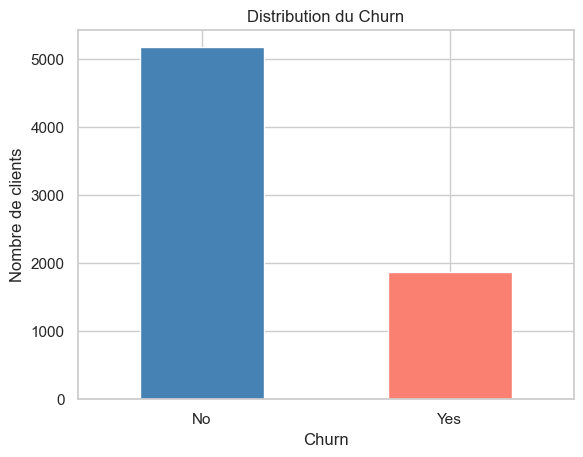

In [6]:
print(df["Churn"].value_counts())

churn_rate = (df["Churn"] == "Yes").mean()
print(f"Taux de churn : {churn_rate:.2%}")

df["Churn"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Distribution du Churn")
plt.xlabel("Churn")
plt.ylabel("Nombre de clients")
plt.xticks(rotation=0)
plt.show()


## 5. Variables numériques vs target

Les 3 colonnes numériques sont `tenure`, `MonthlyCharges`, `TotalCharges`. On veut voir si leur distribution diffère selon que le client churn ou non — c'est le premier signal de **pouvoir prédictif**.

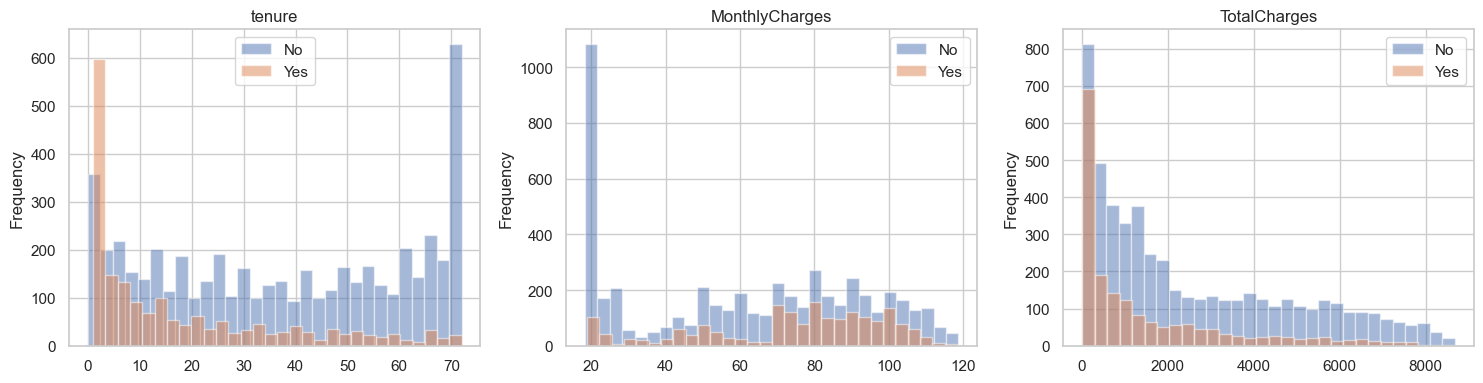

In [7]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    for label, group in df.groupby("Churn")[col]:
        group.plot(kind="hist", ax=ax, alpha=0.5, bins=30, label=label)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()


💡 **Lecture rapide** :
- `tenure` : les churners ont des tenures plus courtes (départs précoces).
- `MonthlyCharges` : les churners paient plus cher par mois — hypothèse : facturation perçue comme excessive.
- `TotalCharges` : suit `tenure × MonthlyCharges` — corrélation attendue, à garder en tête pour la multicolinéarité.

## 6. Variables catégorielles vs target

Pour chaque colonne catégorielle, on calcule le **taux de churn par modalité**. Une grosse variation entre modalités = signal prédictif fort.

In [8]:
cat_cols = [c for c in df.columns
            if df[c].dtype == "object" and c not in ("customerID", "Churn")]
print(f"{len(cat_cols)} categorical columns: {cat_cols}")

def churn_rate_by(col):
    return (
        df.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean())
        .sort_values(ascending=False)
        .rename("churn_rate")
    )

for col in ["Contract", "InternetService", "PaymentMethod"]:
    print(f"\n--- {col} ---")
    print(churn_rate_by(col))


15 categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

--- Contract ---
Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: churn_rate, dtype: float64

--- InternetService ---
InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: churn_rate, dtype: float64

--- PaymentMethod ---
PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: churn_rate, dtype: float64


💡 **Insights métier majeurs** :
- **Contract** : les `Month-to-month` churnent ~3 fois plus que les `Two year`. Logique : pas d'engagement = facilité de départ.
- **InternetService** : `Fiber optic` churn beaucoup plus que `DSL`. Hypothèse : prix perçu trop élevé pour la qualité.
- **PaymentMethod** : `Electronic check` est sur-représenté dans les churners. Hypothèse : signal de friction (paiement manuel mensuel).

🧠 **Réflexe Tech Lead** : ces insights ne sont pas que pour le modèle. Ils alimentent directement les décisions métier (changer la stratégie d'engagement, revoir le pricing fibre, pousser le prélèvement automatique).

## 7. Synthèse de votre EDA

🎯 **Hypothèses emportées de l'EDA :**

1. **tenure** : les clients récents churnent plus → la durée d'abonnement est un signal fort (fidélité = rétention).
2. **Contract** : les contrats mensuels ont ~3× plus de churn que les contrats 2 ans → l'engagement contractuel protège contre le départ.
3. **MonthlyCharges** : les churners paient plus cher par mois → la perception du prix joue un rôle clé dans la décision de résiliation.
4. **InternetService = Fiber optic** : sur-représenté dans les churners → rapport qualité/prix probablement perçu comme insuffisant.
5. **PaymentMethod = Electronic check** : corrélé au churn → signal de friction (paiement manuel mensuel vs prélèvement automatique).


## 8. Train / Validation / Test split

🚨 **Règle d'or** : on splitte **AVANT** tout traitement statistique sur la donnée (imputation, scaling, encoding). Sinon, on a une **fuite** depuis le test set vers le train set.

Le split classique :
- **Train (70 %)** : entraînement du modèle.
- **Validation (15 %)** : choix d'hyperparamètres, comparaison de modèles.
- **Test (15 %)** : score final, vu **une seule fois** à la fin du projet.

On utilise **`stratify=y`** pour conserver le taux de churn dans chaque split (sinon, on peut avoir un split de validation avec un taux de churn très différent, ce qui fausse l'évaluation).

In [9]:
X = df.drop(columns=["customerID", "Churn"])
y = (df["Churn"] == "Yes").astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train):>5} rows | churn rate: {y_train.mean():.2%}")
print(f"Val:   {len(X_val):>5} rows | churn rate: {y_val.mean():.2%}")
print(f"Test:  {len(X_test):>5} rows | churn rate: {y_test.mean():.2%}")


Train:  4930 rows | churn rate: 26.53%
Val:    1056 rows | churn rate: 26.52%
Test:   1057 rows | churn rate: 26.58%


## 9. Sauvegarde des splits

On persiste les splits sur disque pour pouvoir les recharger en TP2 sans tout refaire.

In [10]:
Path("data").mkdir(exist_ok=True)
X_train.to_csv("data/X_train.csv", index=False)
X_val.to_csv("data/X_val.csv", index=False)
X_test.to_csv("data/X_test.csv", index=False)
y_train.to_frame("Churn").to_csv("data/y_train.csv", index=False)
y_val.to_frame("Churn").to_csv("data/y_val.csv", index=False)
y_test.to_frame("Churn").to_csv("data/y_test.csv", index=False)
print("Splits saved to ./data/")


Splits saved to ./data/


## 🚀 Bonus (pour les rapides)

1. **Heatmap de corrélation** : encodez `Churn` en 0/1 et calculez la matrice de corrélation entre les colonnes numériques + churn binaire. Visualisez avec `sns.heatmap`.
2. **Pairplot ciblé** : faites un `sns.pairplot(df[num_cols + ["Churn"]], hue="Churn")` et commentez.
3. **Multicolinéarité** : `TotalCharges ≈ tenure × MonthlyCharges`. Calculez la corrélation. À votre avis, faut-il garder les 3 features ? Justifiez (indice : ça dépend du modèle).
4. **Catégorielles cachées** : certaines colonnes "object" ont 3 modalités dont `"No internet service"` ou `"No phone service"`. Sont-elles vraiment 3 modalités ou plutôt des doublons d'un autre signal ? Inspectez.